## Access Animal Gps Satellite Relay Tagging Realtime Qc (Parquet)
This Jupyter notebook demonstrates how to access and plot animal_gps_satellite_relay_tagging_location_qc_realtime_qc data, available as a [Parquet](https://parquet.apache.org) dataset stored on S3.

🔗 More information about the dataset is available [in the AODN metadata catalogue](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/None).

📌 The source of truth for this notebook is maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/tree/main/notebooks/animal_gps_satellite_relay_tagging_location_qc_realtime_qc.ipynb).


In [1]:
dataset_name = "animal_gps_satellite_relay_tagging_location_qc_realtime_qc"

## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

✅ Virtual environment already exists, skipping creation.


Using Python 3.12.11 environment at: /home/ecougnon/anaconda3/envs/AodnCloudOptimised
Resolved 201 packages in 70ms
Audited 201 packages in 0.11ms


✅ Local version 0.3.25 is up to date (remote: 0.3.25)


In [ ]:
from DataQuery import GetAodn

# Understanding the Dataset

## Understanding Parquet Partitioning

Parquet files can be **partitioned** by one or more columns, which means the data is physically organised into folders based on the values in those columns. This is similar to how databases use indexes to optimise query performance.

Partitioning enables **faster filtering**: when you query data using a partitioned column, only the relevant subset of files needs to be read—improving performance significantly.

For example, if a dataset is partitioned by `"site_code"`, `"timestamp"`, and `"polygon"`, filtering on `"site_code"` allows the system to skip unrelated files entirely.

In this notebook, the `GetAodn` class includes built-in methods to efficiently filter data by **time** and **latitude/longitude** using the **timestamp** and **polygon** partitions. Other partitions can be used for filtering via the `scalar_filter`.

Any filtering on columns that are **not** partitioned can be significantly slower, as all files may need to be scanned. However, the `GetAodn` class provides a `scalar_filter` method that lets you apply these filters at load time—before the data is fully read—helping reduce the size of the resulting DataFrame.

Once the dataset is loaded, further filtering using Pandas is efficient and flexible.

See further below in the notebook for examples of how to filter the data effectively.

To view the actual partition columns for this dataset, run:


In [4]:
aodn = GetAodn()
dname = f'{dataset_name}.parquet'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 7.09 ms, sys: 278 µs, total: 7.36 ms
Wall time: 6.38 ms


In [5]:
aodn_dataset.dataset.partitioning.schema

timestamp: int32
polygon: string
-- schema metadata --
pandas: '{"index_columns": [{"kind": "range", "name": null, "start": 0, "' + 4326

## List unique partition values

In [6]:
%%time
unique_partition_value = aodn_dataset.get_unique_partition_values('YOUR_PARTITION_KEY')
print(list(unique_partition_value)[0:2])  # showing a subset only

[]
CPU times: user 340 µs, sys: 86 µs, total: 426 µs
Wall time: 363 µs


## Visualise Spatial Extent of the dataset
This section plots the polygons representing the areas where data is available. It helps to identify and create a bounding box around the regions containing data.

/home/ecougnon/anaconda3/envs/AodnCloudOptimised/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


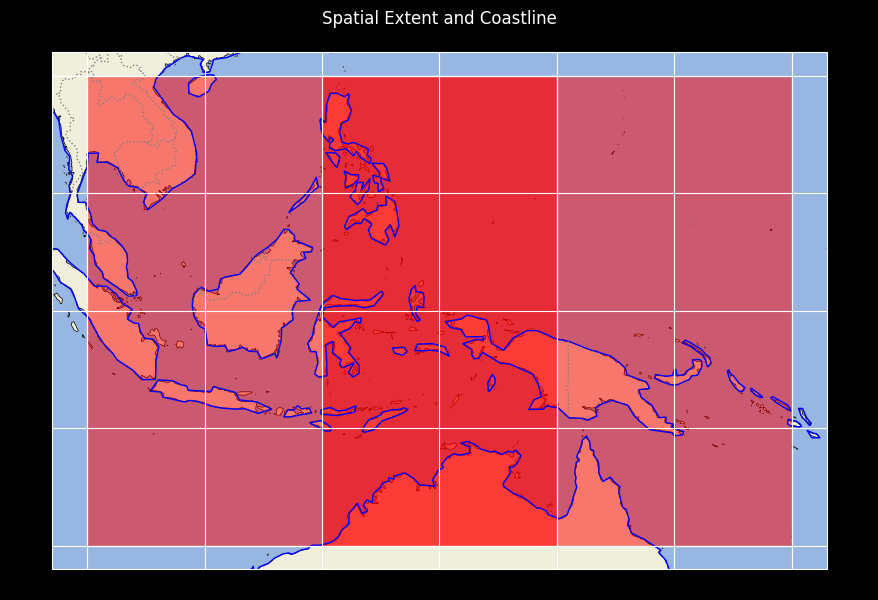

In [7]:
aodn_dataset.plot_spatial_extent()

## Get Temporal Extent of the dataset

Similary to the spatial extent, we're retrieving the minimum and maximum timestamp partition values of the dataset. This is not necessarely accurately representative of the TIME values, as the timestamp partition can be yearly/monthly... but is here to give an idea

In [8]:
%%time
aodn_dataset.get_temporal_extent()

CPU times: user 25.5 ms, sys: 3.7 ms, total: 29.2 ms
Wall time: 215 ms


(Timestamp('2026-05-21 15:32:28+0000', tz='UTC'),
 Timestamp('2026-07-14 07:17:59+0000', tz='UTC'))

## Read Metadata

For all Parquet datasets, we create a sidecar file named **_common_metadata** in the root of the dataset. This file contains both the dataset-level and variable-level attributes.  
The metadata can be retrieved below as a dictionary, and it will also be included in the pandas DataFrame when using the `get_data` method from the `GetAodn` class.

In [9]:
metadata = aodn_dataset.get_metadata()
metadata

2026-07-27 15:21:55,079 - aodn.GetAodn - INFO - Retrieving metadata for imos-optimised-nonproduction/animal_gps_satellite_relay_tagging_location_qc_realtime_qc.parquet


{'iq': {'type': 'int32'},
 'lq': {'type': 'int32'},
 'alt': {'type': 'double'},
 'cid': {'type': 'string', 'comment': 'SMRU campaign name '},
 'cnt': {'type': 'int32',
  'comment': 'The number of times that this record was received'},
 'lat': {'type': 'double',
  'units': 'degrees_north',
  'comment': 'Position estimate (WGS 84 datum)',
  'long_name': 'Latitude'},
 'lon': {'type': 'double',
  'units': 'degrees_east',
  'comment': 'Position estimate (WGS 84 datum)',
  'long_name': 'Longitude'},
 'ptt': {'type': 'int32',
  'comment': 'Argos PTT number is used',
  'long_name': 'Platform Transmitter Terminal'},
 'ref': {'type': 'string',
  'comment': 'A three-part code (e.g. rs3-Fred-07) : The first part identifies the batch of tags, the second part is the name or number of the animal, the third part is the year',
  'long_name': 'reference'},
 'freq': {'type': 'double'},
 'hdop': {'type': 'double'},
 'nops': {'type': 'int32'},
 'nbits': {'type': 'int32',
  'comment': 'Resolution of the tra

# Data Query and Plot

## Create a TIME and BoundingBox filter

This cell loads a subset of the dataset based on a time range and a spatial bounding box. The result is returned as a pandas DataFrame, and basic information about its structure is displayed.

In [10]:
%%time
# NRT dataset, so we re just showing how to do a time filtering here taking the whole data
df = aodn_dataset.get_data(date_start=aodn_dataset.get_temporal_extent()[0].strftime('%Y-%m-%d'),
                           date_end=aodn_dataset.get_temporal_extent()[1].strftime('%Y-%m-%d'),
                           )

df.info()

2026-07-27 15:22:26,195 - aodn.GetAodn - INFO - Retrieving metadata for imos-optimised-nonproduction/animal_gps_satellite_relay_tagging_location_qc_realtime_qc.parquet


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2786 entries, 0 to 2785
Data columns (total 54 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   d_date               2786 non-null   datetime64[us, UTC]
 1   ref                  2786 non-null   object             
 2   ptt                  2786 non-null   int64              
 3   nsats_detected       2786 non-null   int64              
 4   nsats_transmitted    2786 non-null   int64              
 5   gps_mode             2786 non-null   int64              
 6   pseudoranges         2786 non-null   object             
 7   max_csn              0 non-null      float64            
 8   cnt                  2786 non-null   int64              
 9   lat                  2786 non-null   float64            
 10  lon                  2786 non-null   float64            
 11  residual             2786 non-null   float64            
 12  timeshift           

In [13]:
df

,d_date,ref,ptt,nsats_detected,nsats_transmitted,gps_mode,pseudoranges,max_csn,cnt,lat,...,satellite,actual_ptt,best_level,n_mess_120,error_radius,semi_major_axis,semi_minor_axis,ellipse_orientation,timestamp,polygon
0,2026-05-21 15:32:28+00:00,tu126-Marvin-26,40070,10,8,3,29 3fe5 10 28b4 32 5894 23 28b3 26 5ee8 27 58b...,NaN,79,-11.66964,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1767225600,0103000000010000000500000000000000000059400000...
1,2026-05-21 16:24:13+00:00,tu126-James-26,40071,7,7,3,32 7d99 23 2e24 18 3349 10 708 16 44e7 29 4e24...,NaN,272,-11.67454,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1767225600,0103000000010000000500000000000000000059400000...
2,2026-05-21 21:37:06+00:00,tu126-James-26,40071,9,8,3,16 5782 1 821 2 5613 4 7708 3 536a 26 52c9 31 ...,NaN,280,-11.66523,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1767225600,0103000000010000000500000000000000000059400000...
3,2026-05-22 04:56:02+00:00,tu126-Marvin-26,40070,10,8,3,21 6e18 20 66a4 17 72af 22 7b44 19 683f 30 5f4...,NaN,38,-11.74390,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1767225600,0103000000010000000500000000000000000059400000...
4,2026-05-22 11:15:05+00:00,tu126-Marvin-26,40070,9,8,3,18 5724 29 3205 12 ce9 13 61d3 24 36e7 23 22dd...,NaN,47,-11.77617,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1767225600,0103000000010000000500000000000000000059400000...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2781,2026-07-13 15:22:01+00:00,tu126-Naiara-26,40067,8,8,3,32 4300 27 6384 28 2579 2 1694 31 4674 10 2c6d...,NaN,1,-14.93766,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1767225600,0103000000010000000500000000000000000059400000...
2782,2026-07-13 16:24:19+00:00,tu126-Louie-26,41266,10,8,3,8 1777 2 3ac6 31 31fe 27 54e5 16 5862 28 753c ...,NaN,1,-6.88675,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1767225600,0103000000010000000500000000000000000059400000...
2783,2026-07-13 20:07:43+00:00,tu126-Rapunzel-26,41845,8,8,3,3 261f 7 7948 30 2bfc 4 75c5 9 3cbd 5 5f8d 26 ...,NaN,2,-11.91756,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1767225600,0103000000010000000500000000000000000059400000...
2784,2026-07-13 20:47:39+00:00,tu126-Naiara-26,40067,9,8,3,3 4f3f 7 152c 30 98a 9 7fc6 6 627 8 1dd0 14 2d...,NaN,1,-14.93992,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1767225600,0103000000010000000500000000000000000059400000...


In [ ]:
## Download Subsetted Data as CSV

# This cell downloads the filtered dataset as a ZIP-compressed CSV file.  
# The CSV includes metadata at the top as commented lines, and a `FileLink` object is returned to allow downloading directly from the notebook.


df.aodn.download_as_csv()

## Create a TIME and scalar/number filter

This cell filters the dataset by time range and a scalar value (from a Parquet partition) using the `scalar_filter` argument.  
This leverages Parquet partitioning to apply efficient, server-side filtering, which significantly speeds up data loading.

In [15]:
%%time
df = aodn_dataset.get_data(date_start='2026-05-20',
                           date_end='2026-05-23',
                           scalar_filter={'timestamp': 1767225600})
df.info()

2026-07-27 15:27:07,335 - aodn.GetAodn - INFO - Retrieving metadata for imos-optimised-nonproduction/animal_gps_satellite_relay_tagging_location_qc_realtime_qc.parquet


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 54 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   d_date               15 non-null     datetime64[us, UTC]
 1   ref                  15 non-null     object             
 2   ptt                  15 non-null     int64              
 3   nsats_detected       15 non-null     int64              
 4   nsats_transmitted    15 non-null     int64              
 5   gps_mode             15 non-null     int64              
 6   pseudoranges         15 non-null     object             
 7   max_csn              0 non-null      float64            
 8   cnt                  15 non-null     int64              
 9   lat                  15 non-null     float64            
 10  lon                  15 non-null     float64            
 11  residual             15 non-null     float64            
 12  timeshift            15 